In [12]:
from pathlib import Path

import fiona
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BASE_DIR = Path(r"C:\Soilgrids")
DATA_DIR = BASE_DIR / 'data'
TDR_DIR = BASE_DIR / 'TDR_data'
RESULTS_DIR = BASE_DIR / 'resultados'
FIGURES_DIR = BASE_DIR / 'analysis' / 'results_figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

GPKG_PATH = DATA_DIR / 'Ubicacion_Estacion Principal.gpkg'
TDR_RAW_PATH = TDR_DIR / 'TDR_ladera_zhurucay_2021_09_2026_03.csv'
TDR_DAILY_PATH = TDR_DIR / 'TDR_ladera_zhurucay_daily_avg.csv'
TDR_DAILY_MEAN_PATH = TDR_DIR / 'TDR_ladera_zhurucay_daily_mean_all_sensors.csv'
TDR_CLEAN_PATH = RESULTS_DIR / 'TDR_ladera_zhurucay_daily_mean_all_sensors_clean.csv'
SMAP_PATH = TDR_DIR / 'SMAP_RZ_clean.csv'
MISSING_DATES_PATH = RESULTS_DIR / 'missing_dates_daily_mean_all_sensors.csv'
MISSING_GAPS_PATH = RESULTS_DIR / 'missing_gaps_summary_daily_mean_all_sensors.csv'
COMPARISON_DAILY_PATH = RESULTS_DIR / 'comparison_smap_vs_tdr_daily.csv'
COMPARISON_OVERLAP_PATH = RESULTS_DIR / 'comparison_smap_vs_tdr_overlap_only.csv'


def normalize_dates(dataframe, column_name):
    dataframe = dataframe.copy()
    dataframe[column_name] = pd.to_datetime(dataframe[column_name]).dt.normalize()
    return dataframe


def save_figure(fig, filename, dpi=150):
    output_path = FIGURES_DIR / filename
    fig.savefig(output_path, dpi=dpi, bbox_inches='tight')
    print(f"Visualization saved to: {output_path}")
    return output_path


def load_smap_daily():
    smap = pd.read_csv(SMAP_PATH, parse_dates=['datetime'])
    smap = normalize_dates(smap, 'datetime')
    smap = smap.rename(columns={'datetime': 'Date'})
    return (
        smap.groupby('Date', as_index=False)['soil_moisture']
        .mean()
        .sort_values('Date')
    )


def load_tdr_clean():
    tdr = pd.read_csv(TDR_CLEAN_PATH, parse_dates=['Date'])
    tdr = normalize_dates(tdr, 'Date')
    return tdr[['Date', 'VW_mean_all_sensors']].dropna().sort_values('Date')


if GPKG_PATH.exists():
    layers = fiona.listlayers(GPKG_PATH)
    records = []
    source_crs = None

    for layer_name in layers:
        gdf = gpd.read_file(GPKG_PATH, layer=layer_name)
        if gdf.empty:
            continue

        point_rows = gdf[gdf.geometry.geom_type.isin(['Point', 'MultiPoint'])].copy()
        if point_rows.empty:
            continue

        source_crs = gdf.crs
        point_rows['x'] = point_rows.geometry.x
        point_rows['y'] = point_rows.geometry.y
        point_rows['layer'] = layer_name

        if source_crs is not None:
            point_rows_wgs84 = point_rows.to_crs(4326)
            point_rows['longitude'] = point_rows_wgs84.geometry.x
            point_rows['latitude'] = point_rows_wgs84.geometry.y
        else:
            point_rows['longitude'] = pd.NA
            point_rows['latitude'] = pd.NA

        records.append(point_rows[['layer', 'x', 'y', 'longitude', 'latitude', 'geometry']])

    if not records:
        raise ValueError('No point geometries were found in the geopackage.')

    coords_df = pd.concat(records, ignore_index=True)
    print(f'Layers: {list(layers)}')
    print(f'Source CRS: {source_crs}')
else:
    coords_df = pd.DataFrame(columns=['layer', 'x', 'y', 'longitude', 'latitude', 'geometry'])
    print(f'Geopackage not found, skipping coordinate extraction: {GPKG_PATH}')

coords_df

Layers: ['Ubicacion_Estacion Principal']
Source CRS: EPSG:24877


,layer,x,y,longitude,latitude,geometry
0,Ubicacion_Estacion Principal,696444.80038,9.661710e+06,-79.234636,-3.062424,POINT (696444.8 9661710.265)


In [13]:
# Load TDR data and aggregate to daily means
df_tdr = pd.read_csv(TDR_RAW_PATH, parse_dates=['TIMESTAMP'])
df_tdr = df_tdr.drop_duplicates(subset='TIMESTAMP').set_index('TIMESTAMP')
df_day = df_tdr.resample('D').mean()
df_day.index.name = 'Date'

df_day.to_csv(TDR_DAILY_PATH)

print(f'Daily averages saved to: {TDR_DAILY_PATH}')
print(f'Shape: {df_day.shape}')
df_day.head()

Daily averages saved to: C:\Soilgrids\TDR_data\TDR_ladera_zhurucay_daily_avg.csv
Shape: (1659, 12)


,VW_Avg(14),VW_Avg(15),VW_Avg(16),VW_Avg(17),VW_Avg(18),VW_Avg(19),VW_Avg(20),VW_Avg(21),VW_Avg(22),VW_Avg(23),VW_Avg(24),VW_Avg(25)
Date,,,,,,,,,,,,
2021-09-10,0.732906,0.702226,0.726562,0.692944,0.734441,0.762181,0.705681,0.363260,0.678861,0.722021,0.661292,0.819569
2021-09-11,0.733330,0.715705,0.727122,0.691111,0.739132,0.762163,0.706198,0.361917,0.681104,0.722816,0.661615,0.824972
2021-09-12,0.740552,0.736747,0.740740,0.713205,0.751632,0.772743,0.720292,0.394344,0.700215,0.733312,0.696274,0.837531
2021-09-13,0.768399,0.747740,0.757146,0.743052,0.759663,0.778705,0.721969,0.399878,0.707507,0.733139,0.687767,0.836868
2021-09-14,0.759649,0.722806,0.740396,0.729174,0.748774,0.770851,0.712701,0.375840,0.686802,0.728819,0.672569,0.826424


In [14]:
# Compute the mean across all sensors for each day
df_day_mean = df_day.mean(axis=1).rename('VW_mean_all_sensors').to_frame()
df_day_mean.index.name = 'Date'

df_day_mean.to_csv(TDR_DAILY_MEAN_PATH)

print(f'Saved to: {TDR_DAILY_MEAN_PATH}')
print(f'Shape: {df_day_mean.shape}')
df_day_mean.head()

Saved to: C:\Soilgrids\TDR_data\TDR_ladera_zhurucay_daily_mean_all_sensors.csv
Shape: (1659, 1)


,VW_mean_all_sensors
Date,
2021-09-10,0.691829
2021-09-11,0.693932
2021-09-12,0.711466
2021-09-13,0.720153
2021-09-14,0.706234


In [15]:
# Find missing dates in the daily mean soil moisture series
df_daily = pd.read_csv(TDR_DAILY_MEAN_PATH, parse_dates=['Date'])
df_daily = normalize_dates(df_daily, 'Date')
df_daily = df_daily.drop_duplicates(subset='Date').sort_values('Date').set_index('Date')

full_days = pd.date_range(df_daily.index.min(), df_daily.index.max(), freq='D')
missing_from_index = full_days.difference(df_daily.index)
nan_days = df_daily.index[df_daily['VW_mean_all_sensors'].isna()]
all_missing_days = pd.DatetimeIndex(sorted(set(missing_from_index).union(set(nan_days))))

missing_dates_df = pd.DataFrame({'date': all_missing_days.date})
missing_dates_df.to_csv(MISSING_DATES_PATH, index=False)

gap_rows = []
if len(all_missing_days) > 0:
    missing_series = pd.Series(all_missing_days)
    group_id = missing_series.diff().dt.days.ne(1).cumsum()

    for _, group in missing_series.groupby(group_id):
        gap_rows.append({
            'start_date': group.iloc[0].date(),
            'end_date': group.iloc[-1].date(),
            'length_days': int(len(group))
        })

gaps_df = (
    pd.DataFrame(gap_rows).sort_values('length_days', ascending=False)
    if gap_rows
    else pd.DataFrame(columns=['start_date', 'end_date', 'length_days'])
)
gaps_df.to_csv(MISSING_GAPS_PATH, index=False)

print('Missing-date audit complete for daily mean CSV')
print(f'Date range checked: {full_days.min().date()} to {full_days.max().date()}')
print(f'Missing from index: {len(missing_from_index)}')
print(f'NaN days in VW_mean_all_sensors: {len(nan_days)}')
print(f'Total unique missing dates: {len(all_missing_days)}')
print(f'Saved missing dates to: {MISSING_DATES_PATH}')
print(f'Saved gap summary to: {MISSING_GAPS_PATH}')

if len(all_missing_days) > 0:
    print('\nFirst 30 missing dates:')
    print(pd.Series(all_missing_days.date).head(30).to_string(index=False))

if len(gaps_df) > 0:
    print('\nTop 10 largest consecutive missing-date gaps:')
    print(gaps_df.head(10).to_string(index=False))

gaps_df.head(10)

Missing-date audit complete for daily mean CSV
Date range checked: 2021-09-10 to 2026-03-26
Missing from index: 0
NaN days in VW_mean_all_sensors: 246
Total unique missing dates: 246
Saved missing dates to: C:\Soilgrids\resultados\missing_dates_daily_mean_all_sensors.csv
Saved gap summary to: C:\Soilgrids\resultados\missing_gaps_summary_daily_mean_all_sensors.csv

First 30 missing dates:
2023-08-04
2023-08-05
2023-08-06
2023-08-07
2023-08-08
2023-08-09
2024-01-26
2024-01-27
2024-01-28
2024-01-29
2024-01-30
2024-01-31
2024-02-01
2024-02-02
2024-02-03
2024-02-04
2024-02-05
2024-02-06
2024-02-07
2024-02-08
2024-02-09
2024-02-10
2024-02-11
2024-02-12
2024-02-13
2024-02-14
2024-02-15
2024-02-16
2024-02-17
2024-02-18

Top 10 largest consecutive missing-date gaps:
start_date   end_date  length_days
2024-03-22 2024-08-15          147
2024-01-26 2024-02-21           27
2026-02-27 2026-03-12           14
2025-11-20 2025-12-03           14
2025-08-29 2025-09-10           13
2025-12-19 2025-12-31 

,start_date,end_date,length_days
2,2024-03-22,2024-08-15,147
1,2024-01-26,2024-02-21,27
7,2026-02-27,2026-03-12,14
5,2025-11-20,2025-12-03,14
4,2025-08-29,2025-09-10,13
6,2025-12-19,2025-12-31,13
3,2025-08-01,2025-08-12,12
0,2023-08-04,2023-08-09,6


In [23]:
# Remove dates with missing data and store a clean result dataframe
df_daily_full = pd.read_csv(TDR_DAILY_MEAN_PATH, parse_dates=['Date'])
missing_dates_df = pd.read_csv(MISSING_DATES_PATH, parse_dates=['date'])

df_daily_full = normalize_dates(df_daily_full, 'Date')
missing_date_set = set(pd.to_datetime(missing_dates_df['date']).dt.normalize())
known_outlier_dates = {
    pd.Timestamp('2024-11-07'),
    pd.Timestamp('2024-11-14'),
}

df_daily_clean = df_daily_full[~df_daily_full['Date'].isin(missing_date_set)].copy()
df_daily_clean = df_daily_clean[~df_daily_clean['Date'].isin(known_outlier_dates)]
df_daily_clean = df_daily_clean.dropna(subset=['VW_mean_all_sensors'])
df_daily_clean = df_daily_clean.sort_values('Date').reset_index(drop=True)

df_daily_clean.to_csv(TDR_CLEAN_PATH, index=False)

print('Clean dataframe created')
print(f'Original rows: {len(df_daily_full)}')
print(f'Missing dates removed: {len(missing_date_set)}')
print(f'Known outliers removed: {len(known_outlier_dates)}')
print(f'Clean rows: {len(df_daily_clean)}')
print(f'Saved clean dataset to: {TDR_CLEAN_PATH}')

df_daily_clean.head(20)

Clean dataframe created
Original rows: 1659
Missing dates removed: 246
Known outliers removed: 2
Clean rows: 1411
Saved clean dataset to: C:\Soilgrids\resultados\TDR_ladera_zhurucay_daily_mean_all_sensors_clean.csv


,Date,VW_mean_all_sensors
0,2021-09-10,0.691829
1,2021-09-11,0.693932
2,2021-09-12,0.711466
3,2021-09-13,0.720153
4,2021-09-14,0.706234
5,2021-09-15,0.694569
6,2021-09-16,0.688473
7,2021-09-17,0.684290
8,2021-09-18,0.680292
9,2021-09-19,0.677948


Overlapping days before QC: 1412
Rows removed by QC: 1
Overlapping days used: 1411
Correlation (R): 0.4664
RMSE: 0.4063
Bias (SMAP - TDR): -0.4027
Saved comparison table to: C:\Soilgrids\resultados\comparison_smap_vs_tdr_daily.csv
TDR missing/invalid days shown as breaks: 247
SMAP missing/invalid days shown as breaks: 1
Visualization saved to: C:\Soilgrids\analysis\results_figures\results_sm_tdr_vs_smap_timeseries.png


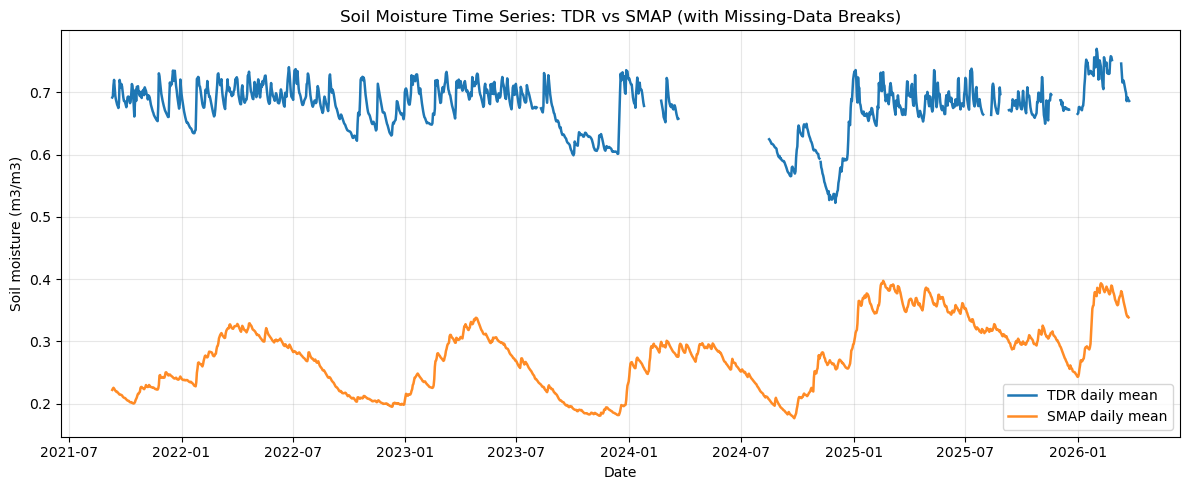

Visualization saved to: C:\Soilgrids\analysis\results_figures\results_sm_tdr_vs_smap_scatter.png


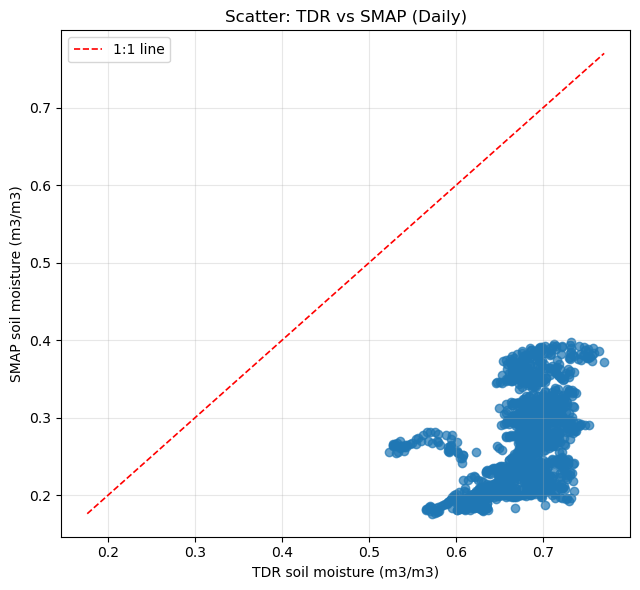

,Date,tdr_soil_moisture,smap_soil_moisture
0,2021-09-10,0.691829,0.222071
1,2021-09-11,0.693932,0.224030
2,2021-09-12,0.711466,0.225418
3,2021-09-13,0.720153,0.224245
4,2021-09-14,0.706234,0.222496


In [17]:
# Compare cleaned TDR daily means with SMAP daily means
tdr = load_tdr_clean()
smap_daily = load_smap_daily()

comparison_raw = pd.merge(tdr, smap_daily, on='Date', how='inner').rename(columns={
    'VW_mean_all_sensors': 'tdr_soil_moisture',
    'soil_moisture': 'smap_soil_moisture'
})

qc_mask = (
    comparison_raw['tdr_soil_moisture'].between(0, 1)
    & comparison_raw['smap_soil_moisture'].between(0, 1)
)
comparison = comparison_raw.loc[qc_mask].copy()
removed = len(comparison_raw) - len(comparison)

r = comparison['tdr_soil_moisture'].corr(comparison['smap_soil_moisture'])
rmse = np.sqrt(np.mean((comparison['smap_soil_moisture'] - comparison['tdr_soil_moisture']) ** 2))
bias = np.mean(comparison['smap_soil_moisture'] - comparison['tdr_soil_moisture'])

print(f'Overlapping days before QC: {len(comparison_raw)}')
print(f'Rows removed by QC: {removed}')
print(f'Overlapping days used: {len(comparison)}')
print(f'Correlation (R): {r:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'Bias (SMAP - TDR): {bias:.4f}')

comparison.to_csv(COMPARISON_DAILY_PATH, index=False)
print(f'Saved comparison table to: {COMPARISON_DAILY_PATH}')

plot_start = min(tdr['Date'].min(), smap_daily['Date'].min())
plot_end = max(tdr['Date'].max(), smap_daily['Date'].max())
full_timeline = pd.date_range(plot_start, plot_end, freq='D')

tdr_plot_src = tdr.copy()
tdr_plot_src.loc[~tdr_plot_src['VW_mean_all_sensors'].between(0, 1), 'VW_mean_all_sensors'] = np.nan
smap_plot_src = smap_daily.copy()
smap_plot_src.loc[~smap_plot_src['soil_moisture'].between(0, 1), 'soil_moisture'] = np.nan

tdr_plot = tdr_plot_src.set_index('Date').reindex(full_timeline)['VW_mean_all_sensors']
smap_plot = smap_plot_src.set_index('Date').reindex(full_timeline)['soil_moisture']

print(f'TDR missing/invalid days shown as breaks: {tdr_plot.isna().sum()}')
print(f'SMAP missing/invalid days shown as breaks: {smap_plot.isna().sum()}')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(full_timeline, tdr_plot, label='TDR daily mean', linewidth=1.8)
ax.plot(full_timeline, smap_plot, label='SMAP daily mean', linewidth=1.8, alpha=0.9)
ax.set_title('Soil Moisture Time Series: TDR vs SMAP (with Missing-Data Breaks)')
ax.set_xlabel('Date')
ax.set_ylabel('Soil moisture (m3/m3)')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
save_figure(fig, 'results_sm_tdr_vs_smap_timeseries.png')
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(comparison['tdr_soil_moisture'], comparison['smap_soil_moisture'], alpha=0.7)
min_val = min(comparison['tdr_soil_moisture'].min(), comparison['smap_soil_moisture'].min())
max_val = max(comparison['tdr_soil_moisture'].max(), comparison['smap_soil_moisture'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.2, label='1:1 line')
ax.set_title('Scatter: TDR vs SMAP (Daily)')
ax.set_xlabel('TDR soil moisture (m3/m3)')
ax.set_ylabel('SMAP soil moisture (m3/m3)')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
save_figure(fig, 'results_sm_tdr_vs_smap_scatter.png')
plt.show()

comparison.head()

Overlap-only SMAP vs TDR
Days used: 1411
Correlation (R): 0.4664
RMSE: 0.4063
Bias (SMAP - TDR): -0.4027
Saved overlap-only table to: C:\Soilgrids\resultados\comparison_smap_vs_tdr_overlap_only.csv
Missing TDR days marked in red: 247
Visualization saved to: C:\Soilgrids\analysis\results_figures\results_sm_continuous_smap_missing_tdr.png


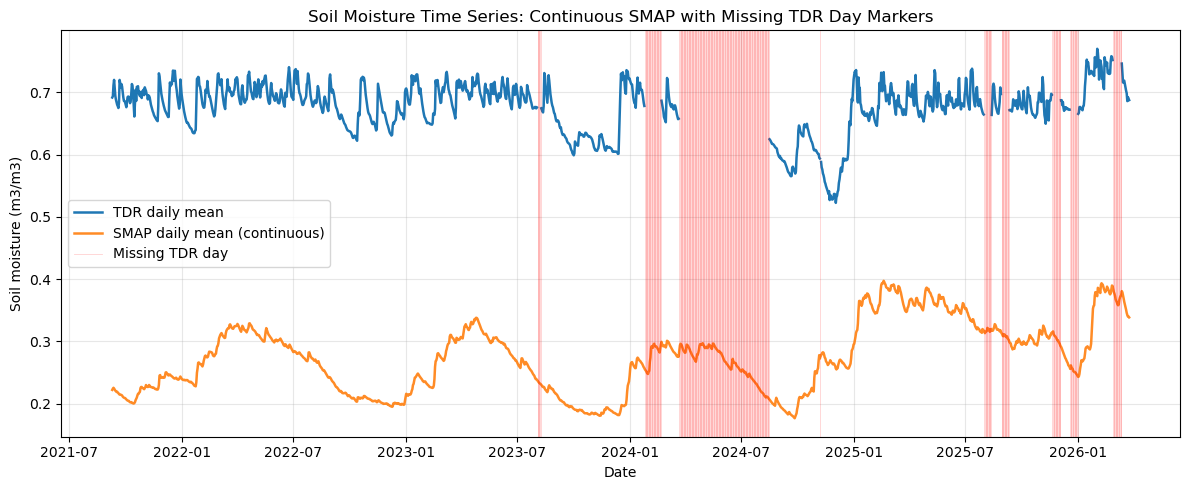

In [18]:
# Overlap-focused metrics, with continuous SMAP and missing TDR day markers
tdr = load_tdr_clean().rename(columns={'VW_mean_all_sensors': 'tdr_soil_moisture'})
smap_daily = load_smap_daily().rename(columns={'soil_moisture': 'smap_soil_moisture'})

overlap = pd.merge(tdr, smap_daily, on='Date', how='inner').sort_values('Date')
overlap = overlap[
    overlap['tdr_soil_moisture'].between(0, 1)
    & overlap['smap_soil_moisture'].between(0, 1)
]

r_overlap = overlap['tdr_soil_moisture'].corr(overlap['smap_soil_moisture'])
rmse_overlap = np.sqrt(np.mean((overlap['smap_soil_moisture'] - overlap['tdr_soil_moisture']) ** 2))
bias_overlap = np.mean(overlap['smap_soil_moisture'] - overlap['tdr_soil_moisture'])

print('Overlap-only SMAP vs TDR')
print(f'Days used: {len(overlap)}')
print(f'Correlation (R): {r_overlap:.4f}')
print(f'RMSE: {rmse_overlap:.4f}')
print(f'Bias (SMAP - TDR): {bias_overlap:.4f}')

overlap.to_csv(COMPARISON_OVERLAP_PATH, index=False)
print(f'Saved overlap-only table to: {COMPARISON_OVERLAP_PATH}')

plot_timeline = pd.date_range(smap_daily['Date'].min(), smap_daily['Date'].max(), freq='D')
smap_plot = smap_daily.set_index('Date').reindex(plot_timeline)['smap_soil_moisture']

tdr_plot_src = tdr.copy()
tdr_plot_src.loc[~tdr_plot_src['tdr_soil_moisture'].between(0, 1), 'tdr_soil_moisture'] = np.nan
tdr_plot = tdr_plot_src.set_index('Date').reindex(plot_timeline)['tdr_soil_moisture']

missing_tdr_days = tdr_plot.index[tdr_plot.isna() & smap_plot.notna()]
print(f'Missing TDR days marked in red: {len(missing_tdr_days)}')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(plot_timeline, tdr_plot, label='TDR daily mean', linewidth=1.8)
ax.plot(plot_timeline, smap_plot, label='SMAP daily mean (continuous)', linewidth=1.8, alpha=0.9)

for index, day in enumerate(missing_tdr_days):
    ax.axvline(
        day,
        color='red',
        linewidth=0.6,
        alpha=0.18,
        label='Missing TDR day' if index == 0 else None
    )

ax.set_title('Soil Moisture Time Series: Continuous SMAP with Missing TDR Day Markers')
ax.set_xlabel('Date')
ax.set_ylabel('Soil moisture (m3/m3)')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
save_figure(fig, 'results_sm_continuous_smap_missing_tdr.png')
plt.show()

Missing TDR days marked in red (z-score plot): 247
Visualization saved to: C:\Soilgrids\analysis\results_figures\results_sm_zscore_continuous_smap.png


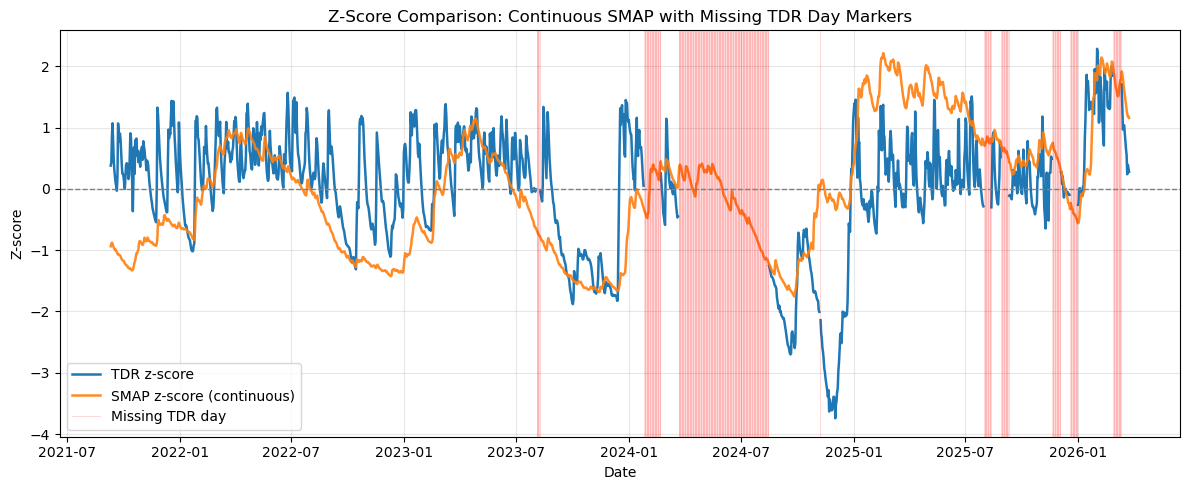

Missing days shown as breaks in overlap-only z-score plot: 247
Visualization saved to: C:\Soilgrids\analysis\results_figures\results_sm_zscore_overlap_only.png


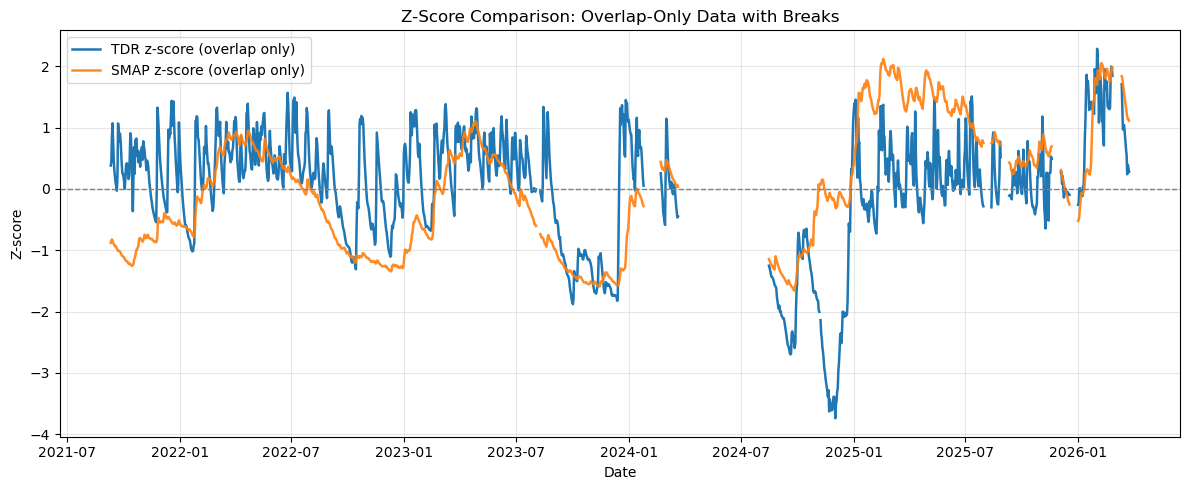

,Date,tdr_z,smap_z
0,2021-09-10,0.380729,-0.880222
1,2021-09-11,0.431930,-0.846670
2,2021-09-12,0.858747,-0.822900
3,2021-09-13,1.070219,-0.842994
4,2021-09-14,0.731391,-0.872950


In [19]:
# Z-score views for SMAP and TDR
overlap_z = pd.read_csv(COMPARISON_OVERLAP_PATH, parse_dates=['Date']).sort_values('Date')

tdr_z = (overlap_z['tdr_soil_moisture'] - overlap_z['tdr_soil_moisture'].mean()) / overlap_z['tdr_soil_moisture'].std()
smap_z = (overlap_z['smap_soil_moisture'] - overlap_z['smap_soil_moisture'].mean()) / overlap_z['smap_soil_moisture'].std()

z_df = pd.DataFrame({
    'Date': overlap_z['Date'],
    'tdr_z': tdr_z,
    'smap_z': smap_z
}).set_index('Date')

smap_full_daily = load_smap_daily()
smap_full_daily['smap_z_full'] = (
    smap_full_daily['soil_moisture'] - smap_full_daily['soil_moisture'].mean()
 ) / smap_full_daily['soil_moisture'].std()

tdr_clean_full = load_tdr_clean().drop_duplicates(subset='Date').sort_values('Date')
missing_days = pd.read_csv(MISSING_DATES_PATH, parse_dates=['date'])
missing_days['date'] = pd.to_datetime(missing_days['date']).dt.normalize()
missing_set = set(missing_days['date'])

tdr_values = tdr_clean_full['VW_mean_all_sensors'].where(
    tdr_clean_full['VW_mean_all_sensors'].between(0, 1)
)
tdr_clean_full['tdr_z_full'] = (tdr_values - tdr_values.mean()) / tdr_values.std()

z_timeline = pd.date_range(smap_full_daily['Date'].min(), smap_full_daily['Date'].max(), freq='D')
smap_z_plot = smap_full_daily.set_index('Date').reindex(z_timeline)['smap_z_full']
tdr_z_plot = tdr_clean_full.set_index('Date').reindex(z_timeline)['tdr_z_full']
tdr_z_plot.loc[tdr_z_plot.index.isin(missing_set)] = pd.NA

missing_tdr_days_z = tdr_z_plot.index[tdr_z_plot.isna() & smap_z_plot.notna()]
print(f'Missing TDR days marked in red (z-score plot): {len(missing_tdr_days_z)}')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(z_timeline, tdr_z_plot, label='TDR z-score', linewidth=1.8)
ax.plot(z_timeline, smap_z_plot, label='SMAP z-score (continuous)', linewidth=1.8, alpha=0.9)

for index, day in enumerate(missing_tdr_days_z):
    ax.axvline(
        day,
        color='red',
        linewidth=0.6,
        alpha=0.18,
        label='Missing TDR day' if index == 0 else None
    )

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Z-Score Comparison: Continuous SMAP with Missing TDR Day Markers')
ax.set_xlabel('Date')
ax.set_ylabel('Z-score')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
save_figure(fig, 'results_sm_zscore_continuous_smap.png')
plt.show()

z_timeline_overlap = pd.date_range(z_df.index.min(), z_df.index.max(), freq='D')
z_plot_overlap = z_df.reindex(z_timeline_overlap)

print(f"Missing days shown as breaks in overlap-only z-score plot: {z_plot_overlap['tdr_z'].isna().sum()}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(z_timeline_overlap, z_plot_overlap['tdr_z'], label='TDR z-score (overlap only)', linewidth=1.8)
ax.plot(z_timeline_overlap, z_plot_overlap['smap_z'], label='SMAP z-score (overlap only)', linewidth=1.8, alpha=0.9)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Z-Score Comparison: Overlap-Only Data with Breaks')
ax.set_xlabel('Date')
ax.set_ylabel('Z-score')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
save_figure(fig, 'results_sm_zscore_overlap_only.png')
plt.show()

z_plot_overlap.reset_index().rename(columns={'index': 'Date'}).head()

Monthly overlap used: 51 months
Visualization saved to: C:\Soilgrids\analysis\results_figures\results_sm_zscore_monthly_averages.png


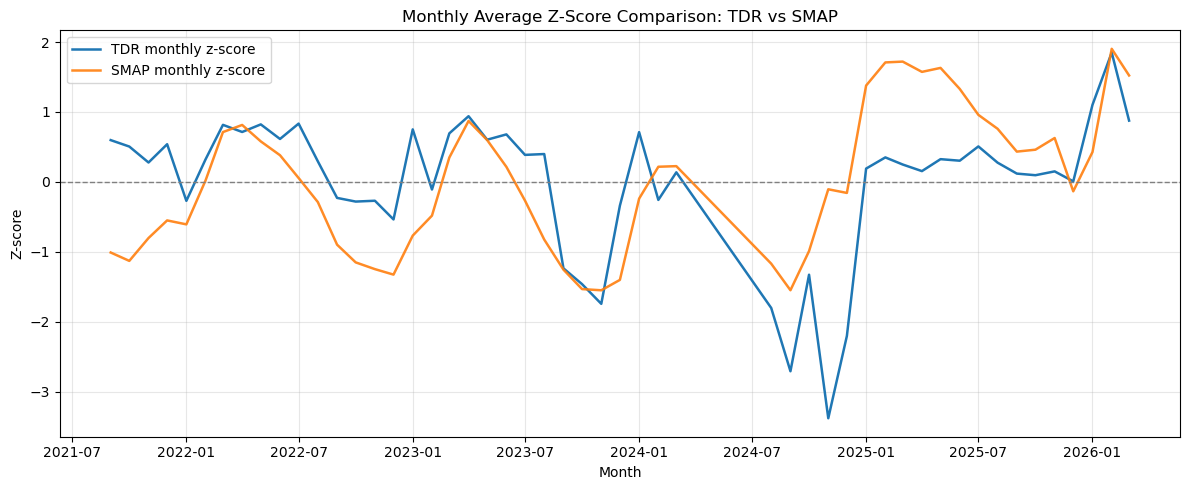

,Month,tdr_monthly_mean,smap_monthly_mean,tdr_monthly_z,smap_monthly_z
0,2021-09-01,0.697107,0.217048,0.596937,-1.010547
1,2021-10-01,0.693904,0.210204,0.504991,-1.130308
2,2021-11-01,0.685953,0.228883,0.276676,-0.803463
3,2021-12-01,0.695058,0.243277,0.538104,-0.551593
4,2022-01-01,0.666858,0.240050,-0.271606,-0.608058


In [25]:
# Monthly-average z-score comparison for TDR and SMAP
tdr_monthly = load_tdr_clean().copy()
tdr_monthly['Month'] = tdr_monthly['Date'].dt.to_period('M').dt.to_timestamp()
tdr_monthly = (
    tdr_monthly.groupby('Month', as_index=False)['VW_mean_all_sensors']
    .mean()
    .rename(columns={'VW_mean_all_sensors': 'tdr_monthly_mean'})
 )

smap_monthly = load_smap_daily().copy()
smap_monthly['Month'] = smap_monthly['Date'].dt.to_period('M').dt.to_timestamp()
smap_monthly = (
    smap_monthly.groupby('Month', as_index=False)['soil_moisture']
    .mean()
    .rename(columns={'soil_moisture': 'smap_monthly_mean'})
 )

monthly_comparison = pd.merge(tdr_monthly, smap_monthly, on='Month', how='inner').sort_values('Month')
monthly_comparison['tdr_monthly_z'] = (
    monthly_comparison['tdr_monthly_mean'] - monthly_comparison['tdr_monthly_mean'].mean()
 ) / monthly_comparison['tdr_monthly_mean'].std()
monthly_comparison['smap_monthly_z'] = (
    monthly_comparison['smap_monthly_mean'] - monthly_comparison['smap_monthly_mean'].mean()
 ) / monthly_comparison['smap_monthly_mean'].std()

print(f"Monthly overlap used: {len(monthly_comparison)} months")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    monthly_comparison['Month'],
    monthly_comparison['tdr_monthly_z'],
    label='TDR monthly z-score',
    linewidth=1.8
 )
ax.plot(
    monthly_comparison['Month'],
    monthly_comparison['smap_monthly_z'],
    label='SMAP monthly z-score',
    linewidth=1.8,
    alpha=0.9
 )
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Monthly Average Z-Score Comparison: TDR vs SMAP')
ax.set_xlabel('Month')
ax.set_ylabel('Z-score')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
save_figure(fig, 'results_sm_zscore_monthly_averages.png')
plt.show()

monthly_comparison.head()